# Abacaxi Capital Management & Equities (ACME) - Rotulação de Notícias Financeiras

## Objetivo
O Objetivo deste projeto é utilizar um modelo preditivo tradicional para rotular textos de acordo com o conteúdo do corpo e comparar seu desempenho com o de Large Language Models modernos (LLMs).

In [8]:
# Importa bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt

In [9]:
# importa dados de data/Dataset.tsv
url = "https://raw.githubusercontent.com/mstagomori/desafio-ciencia-dados-inoa/main/data/Dataset.tsv"

df = pd.read_csv(url, sep="\t")

df.head()

,id,headline,text,asset_class
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities
1,2,"Certificado de deposito bancario oferece 9,6% ...","Certificado de deposito bancario oferece 9,6% ...",fixed_income
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto


## Analise Exploratória

In [ ]:
# Valores nulos
df.isnull().sum()

id             0
headline       0
text           0
asset_class    0
dtype: int64

### Valores Duplicados (Headline e Text)

In [63]:
# Retorna headlines duplicados
df[df.duplicated(subset='headline', keep=False)]

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,259,11,38
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto,65,199,9,29
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities,68,255,10,40
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto,60,256,6,32
5,6,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,294,11,42
...,...,...,...,...,...,...,...,...
5991,5992,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,260,11,40
5992,5993,TelecomOnda reportou queda de 1% no lucro do u...,TelecomOnda reportou queda de 1% no lucro do u...,equities,61,300,10,43
5994,5995,Empresa capta R$ 36 bilhoes em emissao de debe...,Empresa capta R$ 36 bilhoes em emissao de debe...,fixed_income,65,245,10,37
5997,5998,ImobiliariaVicta recebeu recomendacao de compr...,IMOBILIARIAVICTA RECEBEU RECOMENDACAO DE COMPR...,crypto,83,234,10,32


In [64]:
# Retorna text duplicados
df[df.duplicated(subset='text', keep=False)]

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
29,30,Preco da soja sobe na bolsa de graos com quebr...,Preco da soja sobe na bolsa de graos com quebr...,commodities,56,177,12,32
39,40,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,238,11,36
103,104,Rendimento do titulo prefixado avanca com aber...,Rendimento do titulo prefixado avanca com aber...,fixed_income,68,125,11,19
114,115,Cartel de produtores anuncia corte de producao...,Cartel de produtores anuncia corte de producao...,commodities,77,203,12,30
138,139,Governo emite titulos publicos de longo prazo ...,Governo emite titulos publicos de longo prazo ...,fixed_income,67,200,11,31
...,...,...,...,...,...,...,...,...
5916,5917,BelaCosmeticos surpreendeu o mercado com marge...,BelaCosmeticos surpreendeu o mercado com marge...,equities,74,185,10,26
5926,5927,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto,65,200,9,29
5927,5928,Acucar recua na bolsa de acucar com melhora na...,Acucar recua na bolsa de acucar com melhora na...,commodities,60,125,11,21
5930,5931,GAS NATURAL SOBE COM ONDA DE FRIO NO HEMISFERI...,Gas natural sobe com onda de frio no hemisferi...,commodities,53,175,10,28


In [72]:
# Registros com Headline e Text duplicados
print("Número de registros duplicados:", df[df.duplicated(subset=['headline', 'text'], keep=False)].shape[0])
    
# Remove duplicados mantendo o primeiro registro
df = df.drop_duplicates(subset=['headline', 'text'], keep='first')

Número de registros duplicados: 0


In [73]:
# Registros com Text Duplicados
df[df.duplicated(subset='text', keep=False)]

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
138,139,Governo emite titulos publicos de longo prazo ...,Governo emite titulos publicos de longo prazo ...,fixed_income,67,200,11,31
194,195,Cobre sobe com expectativa de demanda por tran...,Cobre sobe com expectativa de demanda por tran...,commodities,62,130,9,19
305,306,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,253,11,38
378,379,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,commodities,62,263,6,39
406,407,Cartel de produtores anuncia corte de producao...,Cartel de produtores anuncia corte de producao...,commodities,79,146,12,22
...,...,...,...,...,...,...,...,...
5263,5264,Governo emite titulos publicos de longo prazo ...,Governo emite titulos publicos de longo prazo ...,crypto,65,200,11,31
5481,5482,TESOURO NACIONAL REALIZA LEILAO DE TITULOS PRE...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,253,11,38
5822,5823,MOEDA LOCAL LIDERA PERDAS ENTRE EMERGENTES NA ...,Moeda local lidera perdas entre emergentes na ...,fx,52,265,8,41
5916,5917,BelaCosmeticos surpreendeu o mercado com marge...,BelaCosmeticos surpreendeu o mercado com marge...,equities,74,185,10,26


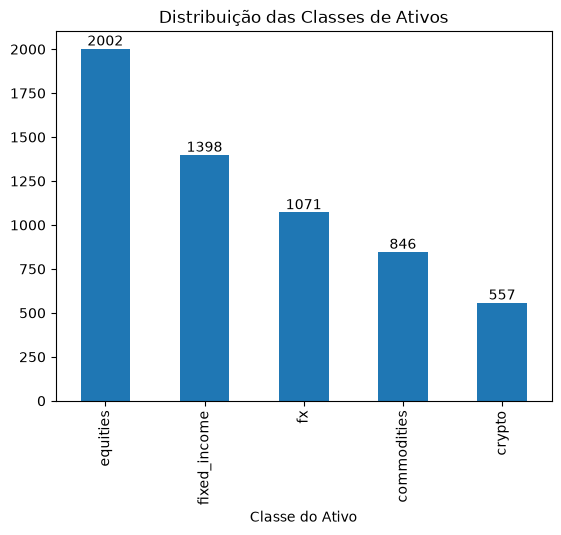

In [70]:
# PLota Distribuição de classes
df['asset_class'].value_counts().plot(kind='bar')
plt.xlabel('Classe do Ativo')
plt.title('Distribuição das Classes de Ativos')
for index, value in enumerate(df['asset_class'].value_counts()):
    plt.text(index, value, str(value), ha='center', va='bottom')
plt.show()

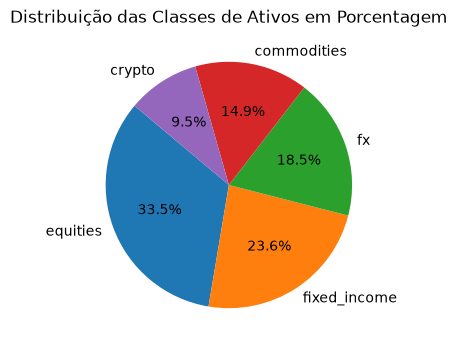

In [35]:
# Distribuição de classes em porcentagem
classes_porcentagem = df['asset_class'].value_counts(normalize=True) * 100

# Plota a distribuição de classes em pie plot
plt.figure(figsize=(4, 4))
plt.pie(classes_porcentagem, labels=classes_porcentagem.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribuição das Classes de Ativos em Porcentagem')
plt.show()

Pode-se perceber um desbalanceamento de classes, com equities e fixed_income tomando mais de 50% dos dados e crypto apenas 9.5%

In [13]:
# Cria novas colunas com o número de caracteres e palavras em 'headline' e 'text'
df['chars_headline'] = df['headline'].fillna('').str.len()
df['chars_text'] = df['text'].fillna('').str.len()

df['words_headline'] = df['headline'].fillna('').str.split().str.len()
df['words_text'] = df['text'].fillna('').str.split().str.len()

### Distribuição de Caracteres e Palavras

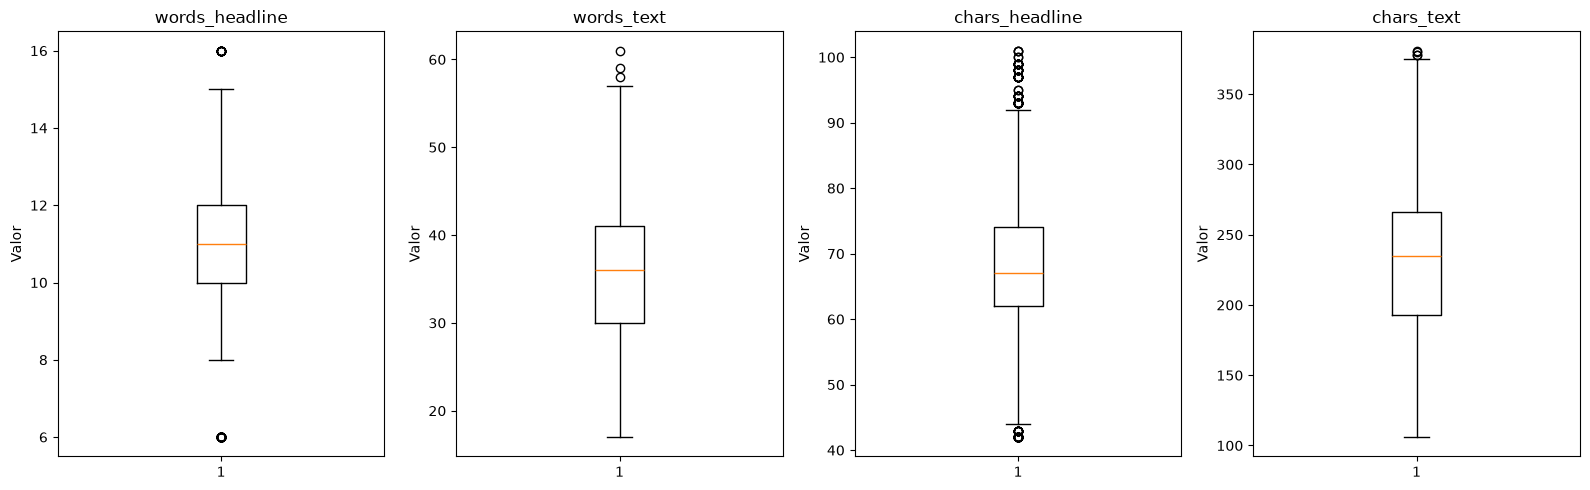

In [ ]:
colunas = [
    'words_headline',
    'words_text',
    'chars_headline',
    'chars_text'
]

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, coluna in zip(axes, colunas):
    ax.boxplot(df[coluna].dropna())
    ax.set_title(coluna)
    ax.set_ylabel('Valor')

plt.tight_layout()
plt.show()

,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
0,1,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,259,11,38
2,3,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto,65,199,9,29
3,4,AeroBras surpreendeu o mercado com margem EBIT...,AeroBras surpreendeu o mercado com margem EBIT...,equities,68,255,10,40
4,5,Investidores institucionais ampliam exposicao ...,Investidores institucionais ampliam exposicao ...,crypto,60,256,6,32
5,6,Milho fecha em alta com clima adverso em regia...,Milho fecha em alta com clima adverso em regia...,commodities,68,294,11,42
...,...,...,...,...,...,...,...,...
5991,5992,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,260,11,40
5992,5993,TelecomOnda reportou queda de 1% no lucro do u...,TelecomOnda reportou queda de 1% no lucro do u...,equities,61,300,10,43
5994,5995,Empresa capta R$ 36 bilhoes em emissao de debe...,Empresa capta R$ 36 bilhoes em emissao de debe...,fixed_income,65,245,10,37
5997,5998,ImobiliariaVicta recebeu recomendacao de compr...,IMOBILIARIAVICTA RECEBEU RECOMENDACAO DE COMPR...,crypto,83,234,10,32


,id,headline,text,asset_class,chars_headline,chars_text,words_headline,words_text
29,30,Preco da soja sobe na bolsa de graos com quebr...,Preco da soja sobe na bolsa de graos com quebr...,commodities,56,177,12,32
39,40,Tesouro nacional realiza leilao de titulos pre...,Tesouro nacional realiza leilao de titulos pre...,fixed_income,78,238,11,36
103,104,Rendimento do titulo prefixado avanca com aber...,Rendimento do titulo prefixado avanca com aber...,fixed_income,68,125,11,19
114,115,Cartel de produtores anuncia corte de producao...,Cartel de produtores anuncia corte de producao...,commodities,77,203,12,30
138,139,Governo emite titulos publicos de longo prazo ...,Governo emite titulos publicos de longo prazo ...,fixed_income,67,200,11,31
...,...,...,...,...,...,...,...,...
5916,5917,BelaCosmeticos surpreendeu o mercado com marge...,BelaCosmeticos surpreendeu o mercado com marge...,equities,74,185,10,26
5926,5927,Aprovacao de fundo negociado de criptoativos i...,Aprovacao de fundo negociado de criptoativos i...,crypto,65,200,9,29
5927,5928,Acucar recua na bolsa de acucar com melhora na...,Acucar recua na bolsa de acucar com melhora na...,commodities,60,125,11,21
5930,5931,GAS NATURAL SOBE COM ONDA DE FRIO NO HEMISFERI...,Gas natural sobe com onda de frio no hemisferi...,commodities,53,175,10,28
